### Import

In [17]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [18]:
import os
import glob
from itertools import product
import numpy as np
import graphical_sampling as gs
import pandas as pd
import pickle
from tqdm import tqdm
from package_sampling.utils import inclusion_probabilities


In [19]:
# os.chdir("/home/bardia/graphical-sampling")
# os.chdir("/home/bardia/graphical-sampling/simulations")
os.chdir('/config/ws/graphical-sampling/simulations')

### Reading Data

In [20]:
dfs ={}
# /config/ws/graphical-sampling/simulations/populations/real
path = "populations/real"
files = ["aggregated.csv", "regular.csv", "meuse.csv", "swiss.csv"]

def popus(n):
    for f in files:
        full_path = os.path.join(path, f)
        df = pd.read_csv(full_path)
        N = len(df)
        
        if f in ["aggregated.csv", "regular.csv"]:
            coords = df.iloc[:, :].to_numpy()
            probs_ep  = np.repeat(n/N, N)
            name = f.replace('.csv', '')
            dfs[f'df_{name}'] = pd.DataFrame(
                {'coord_x':coords[:,0],
                'coord_y':coords[:,1],
                'pik_ep' : probs_ep,}
                )
        ##################################
        if f == "meuse.csv":
            coords = df[['x', 'y']].to_numpy()
            probs_up  = inclusion_probabilities(df['copper'].to_numpy(), n)
            probs_ep  = np.repeat(n/N, N)
            name = f.replace('.csv', '')
            dfs[f'df_{name}'] = pd.DataFrame(
                {'coord_x':coords[:,0],
                'coord_y':coords[:,1],
                'pik_ep' : probs_ep,
                'pik_up' : probs_up,
                'z'      : df['cadmium'], }
                )
        ###################################
        if f == "swiss.csv":
            coords = df[['x', 'y']].to_numpy()
            AREA = df['AREA'].to_numpy().clip(5,100)
            probs_up  = inclusion_probabilities(AREA, n)
            probs_ep  = np.repeat(n/N, N)
            name = f.replace('.csv', '')
            dfs[f'df_{name}'] = pd.DataFrame(
                {'coord_x':coords[:,0],
                'coord_y':coords[:,1],
                'pik_ep' : probs_ep,
                'pik_up' : probs_up,
                'z'      : df['AREA_A'].to_numpy(), }
                )
        ####################################
    return(dfs)


### Random Population and Parameters

<Axes: title={'center': 'FIP Balanced 30-Means Soft Clustering with Zones'}, xlabel='$X_1$', ylabel='$X_2$'>

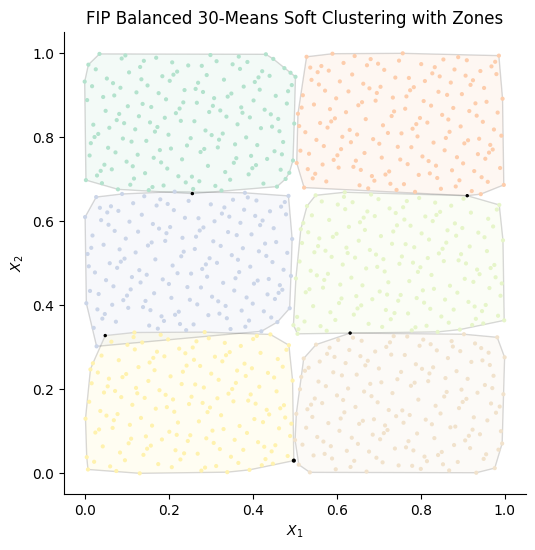

In [38]:
###############################
######## Parameters ###########
###############################
popu = 'df_regular'
ep_or_up = 'pik_ep'
n = 30
r_sample_per_cluster = 5
centroid_grid_x = 6
num_zones_cluster = [4]
num_zones_sweep = [(1, 1)]
num_splits = [1]



df = popus(n)[popu]
N = len(df)
coords = pd.DataFrame(df[['coord_x', 'coord_y']])
inclusions = df[ep_or_up]
variable = df['z'] if 'z' in df.columns else inclusions
pop = gs.Population(coords, inclusions, n=n, variable=variable)
fbn = gs.clustering.FIPBalancedNMeans(n=n, centroid_grid_x = centroid_grid_x, r_sample_per_cluster=r_sample_per_cluster, init_clust_method = 'expanded', split_size = 1)
# fbn = gs.clustering.FIPBalancedNMeans(n=n, r_sample_per_cluster=r_sample_per_cluster, init_clust_method = 'expanded', split_size = 1)

fbn.fit(pop)
fbn.fit_zones(num_zones=num_zones_sweep[0], mode='sweep_xy')
fbn.plot(mode='soft')


### Pre-Process

In [32]:
initial_designs = []
point_strategies = [
      'lexico_yx', 'angle', 'dist_from_origin',
     'dist_from_centroids', 'max_coord',
    'spiral', None,
    'lexico_xy', 'projection',
]
# point_strategies=['spiral', 'lexico_xy']
zone_strategies = [
      'lexico_yx', 'dist_from_origin',
    'spiral', None,
    'lexico_xy', 'projection'
]
# zone_strategies = ['spiral']
zone_modes = [
    # 'cluster',
    'sweep_xy', 
    'sweep_yx'
]
# zone_modes = ['cluster']

track = []
num_designs = len(point_strategies) * len(zone_strategies) * len(zone_modes) * len(num_splits)
min_moran = 0
for _ in range(1):
    
    for point_strategy, zone_strategy, zone_mode, num_split in tqdm(
        product(point_strategies, zone_strategies, zone_modes, num_splits), total=num_designs
    ):
    
        if zone_mode == 'cluster':
            list_of_num_zones = num_zones_cluster
        else:
            list_of_num_zones = num_zones_sweep
    
        for num_zones in list_of_num_zones:
            for _ in range(1):
    
                fbn = gs.clustering.FIPBalancedNMeans(n=n, r_sample_per_cluster=r_sample_per_cluster, init_clust_method = 'expanded', split_size = 1)
                fbn.fit(pop)
                fbn.fit_zones(num_zones=num_zones, mode=zone_mode)
    
                # try:
                order = gs.Order.from_clusters(
                    pop,
                    fbn.clusters,
                    point_strategy,
                    zone_strategy,
                    num_split
                )
                # print("order get",order.get())
                # print("-------------------------------------------------------------------")
                # print("Moran" ,moran)
                # print(point_strategy, zone_strategy, zone_mode, num_zones, num_split)

                # for c in order.clusters:
                #     print("Cluster", c.label)
                #     for i, z in enumerate(c.zones):
                #         print(i)
                #         print("number of zones", order.num_zones)
                #         print("  Zone", i)
                #         print("    indices:", z.indices)
                #         # print("    shares:", z.shares)
                #         # if i > 1:
                #         #     break
                #     break
                design = gs.Design.from_order(pop, order)
    
                initial_designs.append(design)
                moran = design.moran[0]
                # print("number of zones",num_zones)
                # print(moran)
                # print(point_strategy, zone_strategy, zone_mode, num_zones, num_split)
                if moran<min_moran:
                    print(point_strategy, zone_strategy, zone_mode, num_zones, num_split)
                    print(moran)
                    
                    min_moran = moran
                track.append(
                    (moran, design, zone_strategy, point_strategy, zone_mode, num_zones)
                )
z = sorted(track, key=lambda x: x[0], reverse=False)
z[:1]

  3%|█▊                                                              | 3/108 [00:00<00:12,  8.15it/s]

lexico_yx lexico_yx sweep_xy (1, 1) 1
-0.0436975091022109
lexico_yx lexico_yx sweep_yx (1, 1) 1
-0.052126280209167514
lexico_yx dist_from_origin sweep_xy (1, 1) 1
-0.08048223698871065


  6%|████▏                                                           | 7/108 [00:00<00:09, 11.14it/s]

lexico_yx spiral sweep_xy (1, 1) 1
-0.18629944541960974


100%|██████████████████████████████████████████████████████████████| 108/108 [00:08<00:00, 13.13it/s]


[(-0.18629944541960974,
  'spiral',
  'lexico_yx',
  'sweep_xy',
  (1, 1))]

In [33]:
z = sorted(track, key=lambda x: x[0], reverse=False)
initial_moran, initial_design, zs, ps, zm, nz = z[0]

In [34]:
len(initial_design.all_samples_and_probs[0])

50

In [35]:
initial_design.all_samples_and_probs[1].sum()

np.float32(1.0000001)

[[513 706 776 904 395 146 659 914 978 852 281 410 800 545 483  43 235 121
  702 383]]


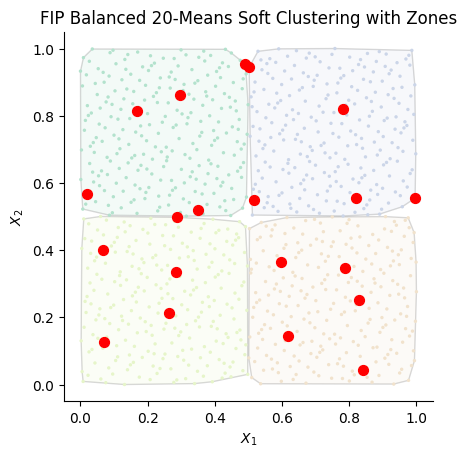

In [36]:
import matplotlib.pyplot as plt

# create figure and axis
fig, ax = plt.subplots()

# first layer: the background plot
criteria = gs.criteria.MoranCriteria()
gbfs = gs.search.GreedyBestFirstSearch([initial_design], criteria)

fbn.plot(mode='soft', ax=ax)   # if the function supports ax

# sample one design point
sample = gbfs.best_design.sample(1)
print(sample)
# coordinates of the population
coords = gbfs.best_design.pop.coords

# scatter layer
ax.scatter(coords[sample, 0], coords[sample, 1], color='red', s=50, zorder=10)

plt.show()


In [19]:
# srs_var = N**2 * (1-n/N) * np.var(variable)/n

# plain_flat = [
#     N,
#     n,
#     5000,
#     0,
#     np.sum(variable),
#     initial_design.nht_variance,
#     # srs_var / initial_design.nht_variance,
#     0,
#     0,
#     initial_design.density_disparity[0],
#     initial_design.density_disparity[1],
#     initial_design.voronoi[0],
#     initial_design.voronoi[1],
#     initial_design.moran[0],
#     initial_design.moran[1],
#     initial_design.local_balance[0],
#     initial_design.local_balance[1],
# ]

# print(", ".join(map(str, plain_flat)))


In [20]:
# import os
# import pickle

# save_dir_designs = "best_design"
# filename = f"initial_design_{popu}_{n}_{ep_or_up}.pkl"
# filename = f"initial_design_{popu}_{n}_{ep_or_up}.pkl"

# filepath = os.path.join(save_dir_designs, filename)

# mode = "load"   # "save" or "load"

# if mode == "save":
#     initial_design = gbfs.best_design
#     with open(filepath, "wb") as f:
#         pickle.dump(initial_design, f)

# elif mode == "load":
#     with open(filepath, "rb") as f:
#         initial_design = pickle.load(f)

# gbfs.best_designs = [initial_design]


### GRIZZLY

In [21]:

# if 1==1:
#     with open(filepath, "rb") as f:
#         best_design = pickle.load(f)
#         gbfs.initial_designs = [best_design]

In [4]:
filepath = "best_design/best_design_df_regular_100_pik_ep.pkl"

with open(filepath, "rb") as f:
    initial_design = pickle.load(f)


FileNotFoundError: [Errno 2] No such file or directory: 'best_design/best_design_df_regular_100_pik_ep.pkl'

In [21]:
initial_design

In [37]:
criteria = gs.criteria.MoranCriteria()
gbfs = gs.search.GreedyBestFirstSearch(initial_designs, criteria)
gbfs.initial_designs = [initial_design]


In [ ]:
gbfs.run(
    max_iterations=10000,        # maximum number of GBFS search iterations (how long the algorithm explores)
    max_open_set_size=200,     # maximum number of candidate designs stored in the priority queue (search frontier)

    top_k=1,                    # number of best designs tracked during the search (best-so-far solutions)

    num_new_order_nodes=100,     # number of neighbors generated by modifying the ordering of samples
                                # (creates 20 candidate designs by changing sample order)

    num_new_exchange_nodes=0,   # number of neighbors generated using exchange moves
                                # (0 means no swapping of units between samples)

    num_clusters_range=(1,1),             # order changes are applied within up to 2 clusters
                                # (clusters are groups of zones processed together)

    num_zones_range=(1, 1),                # within a cluster, modify only 1 zone at a time

    num_changes_range=(1, 1),              # each generated neighbor performs one order modification
                                # (e.g., one swap/reposition in the sequence)

    num_zone_changes=0,         # do not reassign samples between zones (zone structure remains fixed)

    pull_strategy='random',   # rule for selecting samples during exchange operations
                                # (not used here since exchange neighbors are disabled)

    exchange_coef=.5,          # intensity of unit swapping during exchanges
                                # (irrelevant here because num_new_exchange_nodes = 0)

    num_explore=1,               # number of designs expanded per iteration
                                # (1 means purely greedy: always expand the current best design)
    n_jobs = 1
)


--- Starting Parallel GBFS: Max Iterations=10000, Batch Size=1, Workers=1 ---
Initial best criteria value: -0.1863
Iter     0/10000 | Best: -0.1863 | Open:     1 | Closed:     0 | moran: -0.1863
0: -0.1869191,  order_change,  DSize:50,  var:0.00, Entp:3.91
1: -0.1875599,  order_change,  DSize:50,  var:0.00, Entp:3.91
1: -0.1878286,  order_change,  DSize:50,  var:0.00, Entp:3.91
2: -0.1878408,  order_change,  DSize:50,  var:0.00, Entp:3.91
2: -0.1880177,  order_change,  DSize:50,  var:0.00, Entp:3.91
2: -0.1882287,  order_change,  DSize:50,  var:0.00, Entp:3.91
2: -0.1888593,  order_change,  DSize:50,  var:0.00, Entp:3.91
2: -0.1891147,  order_change,  DSize:50,  var:0.00, Entp:3.91
3: -0.1897173,  order_change,  DSize:50,  var:0.00, Entp:3.91
3: -0.1898592,  order_change,  DSize:50,  var:0.00, Entp:3.91
4: -0.1902905,  order_change,  DSize:50,  var:0.00, Entp:3.91
4: -0.1905887,  order_change,  DSize:50,  var:0.00, Entp:3.91
5: -0.1905890,  order_change,  DSize:50,  var:0.00, Entp:3.91

In [1]:
gbfs.initial_designs = [gbfs.best_design]

NameError: name 'gbfs' is not defined

In [2]:
save_dir_designs = "best_design"

filename = f"best_design_{popu}_{n}_{ep_or_up}.pkl"
filepath = os.path.join(save_dir_designs, filename)

# save your design object
with open(filepath, "wb") as f:
    pickle.dump(gbfs.best_design, f)
gbfs.initial_designs = [gbfs.best_design]

NameError: name 'popu' is not defined

In [43]:
srs_var = N**2 * (1-n/N) * np.var(variable)/n
plain_flat = [
    N,
    n,
    5000,
    0,
    np.sum(variable),
    float(gbfs.best_design.nht_variance),
    # float(srs_var / gbfs.best_design.nht_variance),
    0,
    *map(float, gbfs.best_design.density_disparity),
    *map(float, gbfs.best_design.voronoi),
    *map(float, gbfs.best_design.moran),
    *map(float, gbfs.best_design.local_balance),
]
arr = np.array(plain_flat, dtype=float)
simple = [float(x) for x in arr]
# Example: flatten all tuples in the list
flat = []
for x in simple:
    if isinstance(x, tuple):
        flat.extend(x)
    else:
        flat.append(x)

print(', '.join(str(x) for x in flat))




1000.0, 20.0, 5000.0, 0.0, 20.0, 0.0, 0.0, 0.07312242555155238, 0.06845989814904367, 0.04278460302831611, 0.014985923152603841, -0.35131038827771277, 0.04136792596201603, 0.10071685010228261, 0.019506831641670053


# Store

In [38]:
gbfs.best_design.pop.coords

array([[0.49993557, 0.0792481 ],
       [0.24947861, 0.41318937],
       [0.75039252, 0.74712864],
       ...,
       [0.65548937, 0.2789745 ],
       [0.40503242, 0.61291377],
       [0.90594633, 0.94685303]], shape=(999, 2))

In [ ]:
# import numpy as np
# import pandas as pd

# nx = 33
# ny = 30

# x = np.linspace(0, 1, nx)
# y = np.linspace(0, 1, ny)

# xx, yy = np.meshgrid(x, y)

# points = np.column_stack([xx.ravel(), yy.ravel()])

# df = pd.DataFrame(points, columns=["coord_x", "coord_y"])

# print(df)
# print("Total points:", len(df))

# N = len(df)

# coords = pd.DataFrame(df[['coord_x', 'coord_y']])
# inclusions = np.repeat(n/N,N)
# variable = df['z'] if 'z' in df.columns else inclusions

# pop = gs.Population(coords, inclusions, n=n, variable=variable)
# fbn = gs.clustering.FIPBalancedNMeans(n=n, init_clust_method = 'expanded', split_size = 1)
# # fbn.fit(pop)
# # fbn.fit_zones(num_zones=(1, 1), mode='sweep_xy')
# # fbn.plot(mode='hard')


In [39]:
ax = gbfs.best_design.pop


In [40]:
print(type(ax))


<class 'graphical_sampling.population.Population'>


In [41]:
gbfs.best_design.sample(1)

array([[648, 203, 334, 274,  18, 531, 978, 729, 286, 158, 928, 990, 482,
        933, 616, 104, 617, 691, 307, 313]])

In [42]:
 fbn.plot(mode='soft')

<Axes: title={'center': 'FIP Balanced 20-Means Soft Clustering with Zones'}, xlabel='$X_1$', ylabel='$X_2$'>

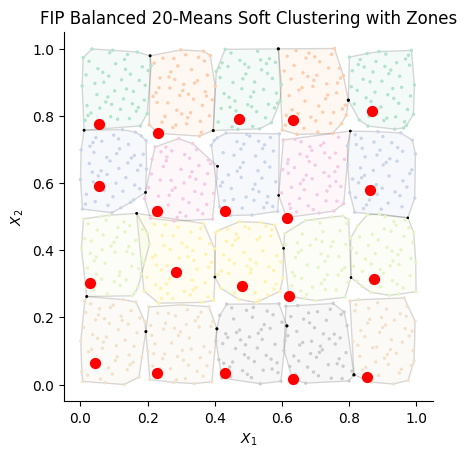

In [43]:
import matplotlib.pyplot as plt

# create figure and axis
fig, ax = plt.subplots()

# first layer: the background plot
fbn.plot(mode='soft', ax=ax)   # if the function supports ax

# sample one design point
sample = gbfs.best_design.sample(1)

# coordinates of the population
coords = gbfs.best_design.pop.coords

# scatter layer
ax.scatter(coords[sample, 0], coords[sample, 1], color='red', s=50, zorder=10)

plt.show()


In [44]:
# sumi = 0
# for i in gbfs.best_design.all_samples_and_probs[1]:
#     sumi += i
#     print(sumi)

In [45]:
raise SystemExit("Stopping Run All: Archived cells below.")

SystemExit: Stopping Run All: Archived cells below.

/home/bardia/graphical-sampling/.venv/lib/python3.10/site-packages/IPython/core/interactiveshell.py:3587: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [ ]:
dir(gbfs.best_design)

In [ ]:

gbfs.best_design.entropy
len(gbfs.best_design.all_samples_and_probs[1])

gbfs.best_design.merge_identical()


print(len(gbfs.best_design.all_samples_and_probs[0]))

In [ ]:
gbfs.best_design